### `pressure_allowed` Binary Classification (Use case A)
#### Will this blocker get beaten on this assignment?

**Pipeline:** Raw `pffScoutingData.csv` + `tracking_parquets/week*.parquet` → features we engineer → model we train → saved artifacts.

##### EDA results
| Fact | Value |
|---|---|
| Pass Block rows | 46,057 in PFF |
| Expected assignments | ~44,402 after tracking join |
| Class balance | ~6.6% positive (14.1:1 imbalance) |
| `separation_min` | 0.829 clean vs 0.655 pressure |
| `rusher_speed_max` | 3.884 clean vs 4.765 pressure |
| `closing_velocity` | 0.419 clean vs 0.251 pressure |
| HB-L pressure rate | 14.2% — HB-R 14.0% — C 4.3% |
| PU block type rate | 17.4% — CL 1.3% |

#### Leakage columns — avoid touching these
- `pff_hitAllowed`, `pff_hurryAllowed`, `pff_sackAllowed` — they **define** the label
- `separation_at_end` — measured after the outcome is resolved

##### Step 1: System setup

In [41]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    classification_report, f1_score
)
import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
NAVY, GOLD, GREEN, RED, AMBER = "#1B3A6B", "#C9A84C", "#2D6A4F", "#9B1C1C", "#B45309"
RANDOM_STATE = 42

ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"
ARTIFACT_DIR = ROOT / "artifacts" / "pressure_allowed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SNAP_EVENTS = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS  = {"pass_forward", "autoevent_passforward",
               "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10

##### Step 2: Load raw data

In [42]:
# PFF scouting data
pff = pd.read_csv(PFF_PATH, na_values=["NA"])
print(f"PFF shape : {pff.shape}   ← expect (188254, 15)")

blockers = pff[pff["pff_role"] == "Pass Block"].copy()
print(f"Pass Block rows: {len(blockers):,}   ← expect 46,057")

# Load tracking
KEEP_COLS = ["gameId", "playId", "nflId", "frameId",
             "x", "y", "s", "a", "dis", "o", "dir", "event"]

weeks = []
for i in range(1, 9):
    w = pd.read_parquet(
        TRACKING_DIR / f"week{i}.parquet",
        engine="pyarrow", columns=KEEP_COLS
    )
    weeks.append(w)
    print(f"  week{i}: {len(w):,} rows")

tracking = pd.concat(weeks, ignore_index=True)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)
print(f"\nAll weeks: {len(tracking):,} player rows")

PFF shape : (188254, 15)   ← expect (188254, 15)
Pass Block rows: 46,057   ← expect 46,057
  week1: 1,118,122 rows
  week2: 1,042,774 rows
  week3: 560,908 rows
  week4: 560,917 rows
  week5: 1,074,606 rows
  week6: 1,097,813 rows
  week7: 973,797 rows
  week8: 1,885,241 rows

All weeks: 7,952,692 player rows


##### Step 3: Build snap-to-event windows

In [43]:
def build_play_windows(tracking: pd.DataFrame) -> pd.DataFrame:
    """
    Return (gameId, playId, snap_frame, end_frame, window_duration_s)
    """
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")
        snap_frames = events.loc[events["event"].isin(SNAP_EVENTS), "frameId"]
        if snap_frames.empty:
            continue
        snap_frame = snap_frames.min()
        end_frames = events.loc[
            events["event"].isin(END_EVENTS) & (events["frameId"] > snap_frame),
            "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()
        rows.append({
            "gameId": gid, "playId": pid,
            "snap_frame": snap_frame, "end_frame": end_frame,
            "window_duration_s": (end_frame - snap_frame + 1) / TRACKING_FPS
        })
    return pd.DataFrame(rows)

windows = build_play_windows(tracking)
print(f"Windows : {len(windows):,} plays")
print(windows[["window_duration_s"]].describe().round(2).to_string())

Windows : 8,533 plays
       window_duration_s
count            8533.00
mean                3.25
std                 1.27
min                 0.60
25%                 2.40
50%                 2.90
75%                 3.70
max                19.30


##### Step 4: Build blocker–rusher pairs

`pff_nflIdBlockedPlayer` tells us which rusher each Pass Block row was assigned to.
This is the join key for the one-on-one matchup.

In [44]:
# Build assignment pairs from PFF scouting data

assignments = (
    blockers
    .dropna(subset=["pff_nflIdBlockedPlayer"])
    [["gameId", "playId", "nflId",
      "pff_positionLinedUp", "pff_blockType", "pff_backFieldBlock",
      "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed",
      "pff_nflIdBlockedPlayer"]]
    .copy()
)
assignments["pff_nflIdBlockedPlayer"] = assignments["pff_nflIdBlockedPlayer"].astype(int)
assignments = assignments.rename(columns={
    "nflId"                  : "blocker_nflId",
    "pff_nflIdBlockedPlayer"  : "rusher_nflId",
})
# Fill NaN block type with 'UNKNOWN'
assignments["pff_blockType"] = assignments["pff_blockType"].fillna("UNKNOWN")
assignments["pff_backFieldBlock"] = assignments["pff_backFieldBlock"].fillna(0.0)

print(f"Assignment pairs: {len(assignments):,}")

Assignment pairs: 44,526


##### Step 5: Engineer matchup features

For each blocker–rusher pair, compute tracking-derived signals over the snap-to-event window:
separation at snap, minimum separation (closest approach), closing velocity, and both players' speed/acceleration.

In [45]:
# Restrict tracking to snap→end window
windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["snap_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()
print(f"Windowed player frames: {len(windowed):,}")

Windowed player frames: 6,097,366


In [46]:
# Build per-player speed/accel summaries
player_stats = (
    windowed
    .groupby(["gameId", "playId", "nflId"])
    .agg(
        speed_mean=("s", "mean"),
        speed_max =("s", "max"),
        accel_mean=("a", "mean"),
        n_frames  =("frameId", "count"),
    )
    .reset_index()
)
print(f"Player stats rows: {len(player_stats):,}")

Player stats rows: 187,726


In [47]:
# Compute frame-by-frame separation for each assignment
# For each frame in the window, measure Euclidean distance between
# blocker and rusher. Derive: separation_at_snap, separation_min, closing_velocity.

def compute_separation_features(assignments, windowed, windows):
    records = []

    # Index windowed tracking for fast lookup
    trk = windowed.set_index(["gameId", "playId", "nflId"])

    for _, row in assignments.iterrows():
        gid = row["gameId"]
        pid = row["playId"]
        bid = row["blocker_nflId"]
        rid = row["rusher_nflId"]

        try:
            b = trk.loc[(gid, pid, bid)].sort_values("frameId")
            r = trk.loc[(gid, pid, rid)].sort_values("frameId")
        except KeyError:
            continue  # one of the players not in tracking for this window

        # Align on common frames
        common = pd.merge(
            b[["frameId", "x", "y"]].rename(columns={"x":"bx","y":"by"}),
            r[["frameId", "x", "y"]].rename(columns={"x":"rx","y":"ry"}),
            on="frameId"
        )
        if len(common) < 2:
            continue

        dist = np.sqrt((common["bx"]-common["rx"])**2 +
                       (common["by"]-common["ry"])**2)

        sep_at_snap = dist.iloc[0]
        sep_min     = dist.min()
        # closing_velocity: positive = gap closing, negative = gap opening
        closing_vel = (sep_at_snap - dist.iloc[-1]) / (len(common) / TRACKING_FPS)

        records.append({
            "gameId"           : gid,
            "playId"           : pid,
            "blocker_nflId"    : bid,
            "rusher_nflId"     : rid,
            "separation_at_snap": sep_at_snap,
            "separation_min"   : sep_min,
            "closing_velocity" : closing_vel,
            "n_frames"         : len(common),
        })

    return pd.DataFrame(records)


sep_features = compute_separation_features(assignments, windowed, windows)
print(f"Separation features rows: {len(sep_features):,}")

Separation features rows: 44,403


In [48]:
# Assemble full feature table
# Join: assignment pairs + separation features + blocker stats + rusher stats + window duration

feature_table = assignments.merge(
    sep_features, on=["gameId", "playId", "blocker_nflId", "rusher_nflId"], how="inner"
)

# Blocker movement stats
feature_table = feature_table.merge(
    player_stats.rename(columns={
        "nflId"     : "blocker_nflId",
        "speed_mean": "blocker_speed_mean",
        "speed_max" : "blocker_speed_max",
        "accel_mean": "blocker_accel_mean",
        "n_frames"  : "_blocker_frames",
    }),
    on=["gameId", "playId", "blocker_nflId"], how="left"
)

# Rusher movement stats
feature_table = feature_table.merge(
    player_stats.rename(columns={
        "nflId"     : "rusher_nflId",
        "speed_mean": "rusher_speed_mean",
        "speed_max" : "rusher_speed_max",
        "accel_mean": "rusher_accel_mean",
        "n_frames"  : "_rusher_frames",
    }),
    on=["gameId", "playId", "rusher_nflId"], how="left"
)

# Window duration from windows table
feature_table = feature_table.merge(
    windows[["gameId", "playId", "window_duration_s"]],
    on=["gameId", "playId"], how="left"
)

feature_table = feature_table.drop(columns=["_blocker_frames", "_rusher_frames"])
feature_table = feature_table.reset_index(drop=True)
feature_table.insert(0, "assignment_id", feature_table.index)

print(f"Feature table shape: {feature_table.shape}")
print(feature_table.dtypes.to_string())

Feature table shape: (44403, 22)
assignment_id            int64
gameId                   int64
playId                   int64
blocker_nflId            int64
pff_positionLinedUp     object
pff_blockType           object
pff_backFieldBlock     float64
pff_hitAllowed         float64
pff_hurryAllowed       float64
pff_sackAllowed        float64
rusher_nflId             int64
separation_at_snap     float64
separation_min         float64
closing_velocity       float64
n_frames                 int64
blocker_speed_mean     float64
blocker_speed_max      float64
blocker_accel_mean     float64
rusher_speed_mean      float64
rusher_speed_max       float64
rusher_accel_mean      float64
window_duration_s      float64


##### Step 6: Build label

In [49]:
# pressure_allowed = 1 if ANY of hit/hurry/sack was allowed
# This is our target. The three source columns are leakage — drop after.

feature_table["pressure_allowed"] = (
    (feature_table["pff_hitAllowed"]   == 1) |
    (feature_table["pff_hurryAllowed"] == 1) |
    (feature_table["pff_sackAllowed"]  == 1)
).astype(int)

neg, pos = feature_table["pressure_allowed"].value_counts()
print(f"Clean blocks     : {neg:,}   ← expect ~41,453")
print(f"Pressure allowed : {pos:,}   ← expect ~2,949")
print(f"Positive rate    : {pos/len(feature_table):.3%}   ← expect 6.6%")
print(f"Imbalance ratio  : {neg/pos:.1f}:1   ← expect 14.1:1")

# Confirm EDA tracking feature means match
dist_check = (
    feature_table
    .groupby("pressure_allowed")[["separation_min", "closing_velocity", "rusher_speed_max"]]
    .mean().round(3)
    .rename(index={0: "Clean block", 1: "Pressure allowed"})
)
print("\nFeature means by outcome (EDA: sep_min 0.829/0.655, cv 0.419/0.251, spd 3.884/4.765):")
print(dist_check.to_string())

Clean blocks     : 41,454   ← expect ~41,453
Pressure allowed : 2,949   ← expect ~2,949
Positive rate    : 6.641%   ← expect 6.6%
Imbalance ratio  : 14.1:1   ← expect 14.1:1

Feature means by outcome (EDA: sep_min 0.829/0.655, cv 0.419/0.251, spd 3.884/4.765):
                  separation_min  closing_velocity  rusher_speed_max
pressure_allowed                                                    
Clean block                0.829             0.419             3.884
Pressure allowed           0.655             0.251             4.765


##### Step 7: Prepare Model Input

In [50]:
TARGET = "pressure_allowed"

# Columns that must NEVER enter the model
LEAKAGE  = ["pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed"]
IDENTITY = ["assignment_id", "gameId", "playId", "blocker_nflId", "rusher_nflId"]

CAT_COLS = ["pff_positionLinedUp", "pff_blockType"]
NUM_COLS = [
    "pff_backFieldBlock",
    "separation_at_snap",
    "separation_min",
    "closing_velocity",
    "blocker_speed_mean", "blocker_speed_max", "blocker_accel_mean",
    "rusher_speed_mean",  "rusher_speed_max",  "rusher_accel_mean",
    "window_duration_s",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

# Encode categoricals
df_model = feature_table.copy()
encoders = {}
for col in CAT_COLS:
    enc = LabelEncoder()
    df_model[col] = enc.fit_transform(df_model[col].astype(str))
    encoders[col] = enc
    print(f"{col}: {enc.classes_.tolist()}")

print(f"\nTotal features: {len(FEATURE_COLS)}")

pff_positionLinedUp: ['C', 'FB', 'FB-L', 'FB-R', 'HB', 'HB-L', 'HB-R', 'LG', 'LT', 'LWR', 'RG', 'RT', 'RWR', 'SLWR', 'SLiWR', 'SLoWR', 'SRWR', 'SRiWR', 'SRoWR', 'TE-L', 'TE-R', 'TE-iL', 'TE-iR', 'TE-oL', 'TE-oR']
pff_blockType: ['BH', 'CH', 'CL', 'PA', 'PP', 'PR', 'PT', 'PU', 'SR', 'SW', 'UP']

Total features: 13


##### Step 8: Train / Test Split

In [51]:
X      = df_model[FEATURE_COLS].values
y      = df_model[TARGET].values
groups = feature_table["gameId"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Game overlap (must be 0): {len(set(groups[train_idx]) & set(groups[test_idx]))}")
print(f"Train positive rate: {y_train.mean():.3%}")
print(f"Test  positive rate: {y_test.mean():.3%}")

Train: 35,362  Test: 9,041
Game overlap (must be 0): 0
Train positive rate: 6.631%
Test  positive rate: 6.681%


##### Step 9: Baseline

In [52]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_dummy_prob     = dummy.predict_proba(X_test)[:, 1]
baseline_pr_auc  = average_precision_score(y_test, y_dummy_prob)
baseline_roc_auc = roc_auc_score(y_test, y_dummy_prob)
print(f"Baseline PR-AUC  : {baseline_pr_auc:.4f}  (≈ positive rate)")
print(f"Baseline ROC-AUC : {baseline_roc_auc:.4f}  (≈ 0.5)")

Baseline PR-AUC  : 0.0670  (≈ positive rate)
Baseline ROC-AUC : 0.5013  (≈ 0.5)


##### Step 10: Logistic Regression (Interpretable Benchmark)

In [53]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ))
])
lr_pipe.fit(X_train, y_train)
y_lr_prob    = lr_pipe.predict_proba(X_test)[:, 1]
lr_pr_auc    = average_precision_score(y_test, y_lr_prob)
lr_roc_auc   = roc_auc_score(y_test, y_lr_prob)
print(f"LR PR-AUC  : {lr_pr_auc:.4f}")
print(f"LR ROC-AUC : {lr_roc_auc:.4f}")

LR PR-AUC  : 0.2005
LR ROC-AUC : 0.8092


##### Step 11: HistGradientBoosting (Cross-Validated & Tuned)

In [54]:
# HistGradientBoostingClassifier — GroupKFold cross-validated hyperparameter search.
# CV runs only on the TRAIN split (X_train/y_train/groups[train_idx]) — the held-out
# test set below stays untouched for every downstream metric (evaluation, threshold
# tuning, SHAP, risk-score analysis, error analysis).

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "max_depth"        : randint(3, 7),
    "learning_rate"    : uniform(0.02, 0.13),   # 0.02–0.15
    "min_samples_leaf" : randint(10, 50),
    "max_leaf_nodes"   : randint(15, 63),
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train, groups=groups[train_idx])

hgbt          = search.best_estimator_
cv_score_mean = search.best_score_
cv_score_std  = search.cv_results_["std_test_score"][search.best_index_]

print(f"Best params  : {search.best_params_}")
print(f"CV PR-AUC    : {cv_score_mean:.4f} ± {cv_score_std:.4f}  (5-fold, grouped by gameId)")

y_prob  = hgbt.predict_proba(X_test)[:, 1]
pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"Iterations   : {hgbt.n_iter_}")
print(f"HGBT PR-AUC  : {pr_auc:.4f}   (LR={lr_pr_auc:.4f}, baseline={baseline_pr_auc:.4f})  ← held-out test set")
print(f"HGBT ROC-AUC : {roc_auc:.4f}")

Best params  : {'learning_rate': np.float64(0.02755086958186593), 'max_depth': 6, 'max_leaf_nodes': 50, 'min_samples_leaf': 49}
CV PR-AUC    : 0.3207 ± 0.0129  (5-fold, grouped by gameId)
Iterations   : 180
HGBT PR-AUC  : 0.2945   (LR=0.2005, baseline=0.0670)  ← held-out test set
HGBT ROC-AUC : 0.8499


##### Step 12: Evaluation

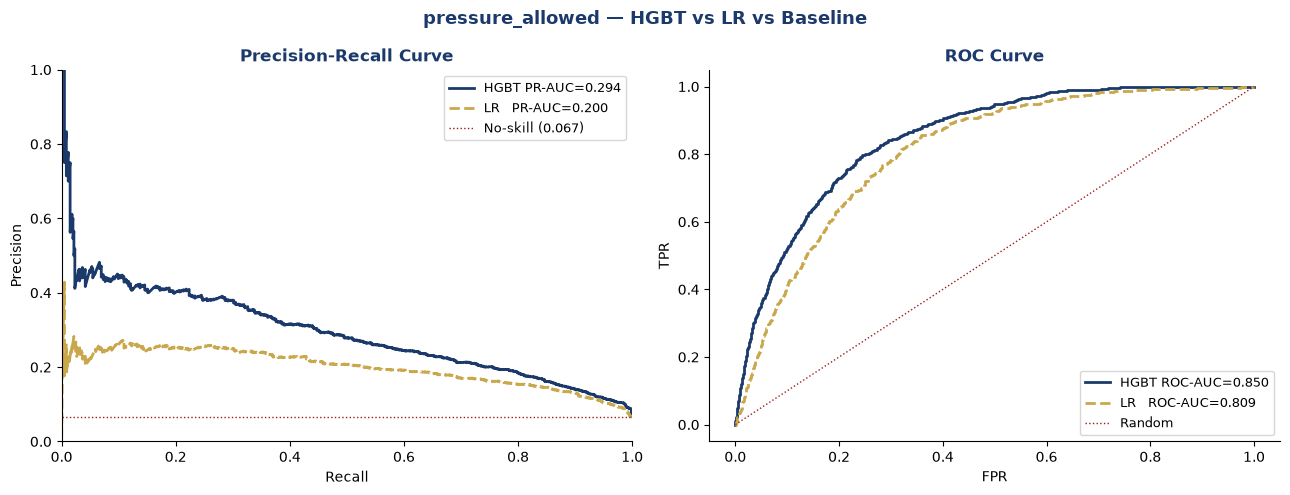

In [55]:
# PR and ROC curves
prec_h, rec_h, _ = precision_recall_curve(y_test, y_prob)
prec_l, rec_l, _ = precision_recall_curve(y_test, y_lr_prob)
fpr_h, tpr_h, _  = roc_curve(y_test, y_prob)
fpr_l, tpr_l, _  = roc_curve(y_test, y_lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_h, prec_h, color=NAVY, lw=2, label=f"HGBT PR-AUC={pr_auc:.3f}")
axes[0].plot(rec_l, prec_l, color=GOLD, lw=2, ls="--", label=f"LR   PR-AUC={lr_pr_auc:.3f}")
axes[0].axhline(y_test.mean(), color=RED, ls=":", lw=1, label=f"No-skill ({y_test.mean():.3f})")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve", xlim=[0,1], ylim=[0,1])
axes[0].legend(fontsize=9)
axes[0].title.set(fontweight="bold", color=NAVY)

axes[1].plot(fpr_h, tpr_h, color=NAVY, lw=2, label=f"HGBT ROC-AUC={roc_auc:.3f}")
axes[1].plot(fpr_l, tpr_l, color=GOLD, lw=2, ls="--", label=f"LR   ROC-AUC={lr_roc_auc:.3f}")
axes[1].plot([0,1],[0,1], color=RED, ls=":", lw=1, label="Random")
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[1].legend(fontsize=9)
axes[1].title.set(fontweight="bold", color=NAVY)

plt.suptitle("pressure_allowed — HGBT vs LR vs Baseline",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

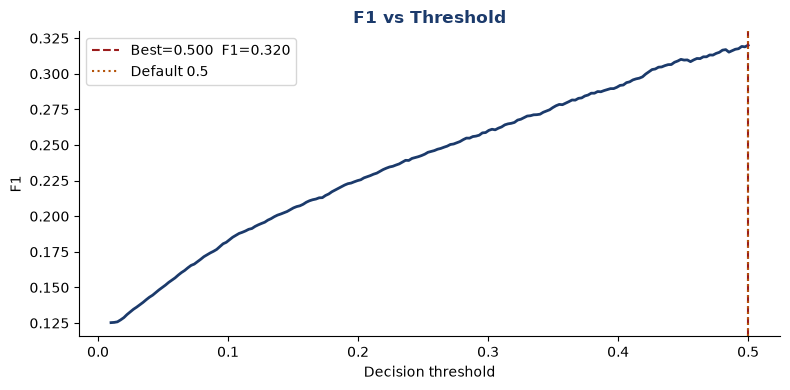

Optimal threshold : 0.500
F1 at threshold   : 0.3201

                  precision    recall  f1-score   support

     Clean block       0.98      0.80      0.88      8437
Pressure allowed       0.20      0.73      0.32       604

        accuracy                           0.79      9041
       macro avg       0.59      0.76      0.60      9041
    weighted avg       0.92      0.79      0.84      9041



In [56]:
# Optimal threshold (default 0.5 is wrong for 6.6% positive rate)
thresh_range = np.linspace(0.01, 0.5, 200)
f1_scores    = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresh_range]
best_thresh  = thresh_range[np.argmax(f1_scores)]
best_f1      = max(f1_scores)
y_pred_opt   = (y_prob >= best_thresh).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_range, f1_scores, color=NAVY, lw=2)
ax.axvline(best_thresh, color=RED, ls="--", label=f"Best={best_thresh:.3f}  F1={best_f1:.3f}")
ax.axvline(0.5, color=AMBER, ls=":", label="Default 0.5")
ax.set(xlabel="Decision threshold", ylabel="F1", title="F1 vs Threshold")
ax.title.set(fontweight="bold", color=NAVY)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold : {best_thresh:.3f}")
print(f"F1 at threshold   : {best_f1:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["Clean block", "Pressure allowed"]))

##### Step 13: Feature Importance

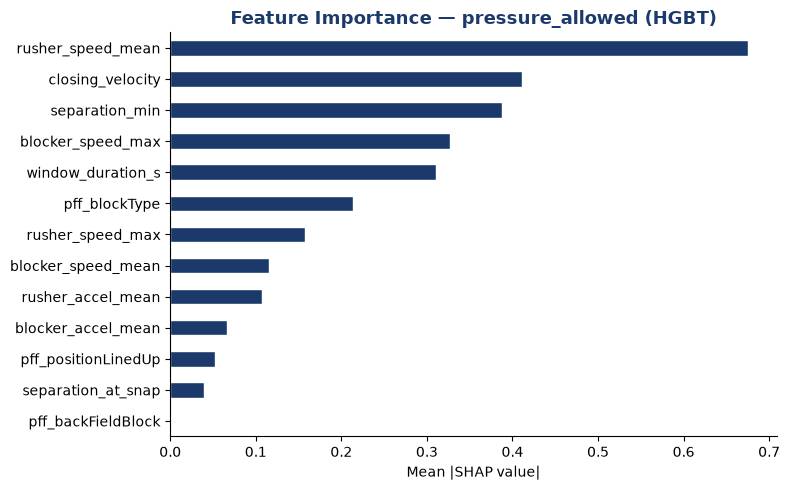

rusher_speed_mean      0.675188
closing_velocity       0.410677
separation_min         0.387657
blocker_speed_max      0.327428
window_duration_s      0.310458
pff_blockType          0.213074
rusher_speed_max       0.157141
blocker_speed_mean     0.115282
rusher_accel_mean      0.107055
blocker_accel_mean     0.066589
pff_positionLinedUp    0.051839
separation_at_snap     0.038945
pff_backFieldBlock     0.000981


In [57]:
import shap
explainer = shap.TreeExplainer(hgbt)
shap_values = explainer.shap_values(X_test) 
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS, name="importance"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color=NAVY, edgecolor="white")
ax.set_title("Feature Importance — pressure_allowed (HGBT)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).to_string())

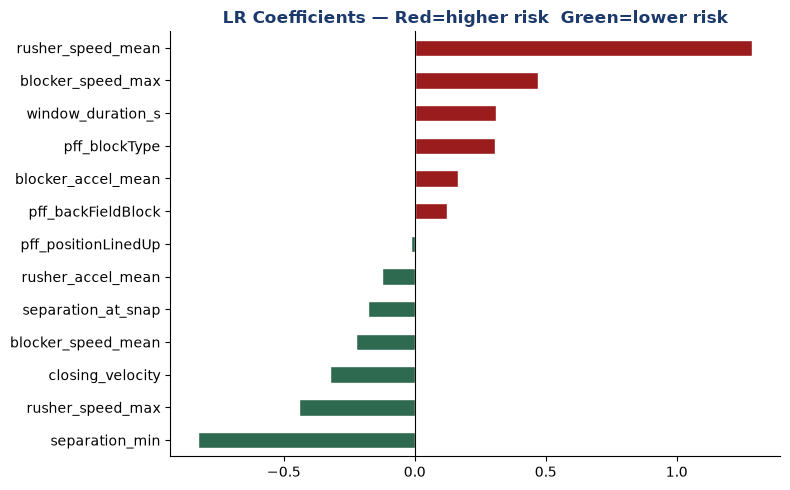

In [58]:
# LR coefficients — direction of each feature's effect
lr_coef = pd.Series(
    lr_pipe.named_steps["clf"].coef_[0], index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
lr_coef.plot(kind="barh", ax=ax,
             color=[RED if c > 0 else GREEN for c in lr_coef], edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("LR Coefficients — Red=higher risk  Green=lower risk",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

##### Step 14: Risk Score Analysis

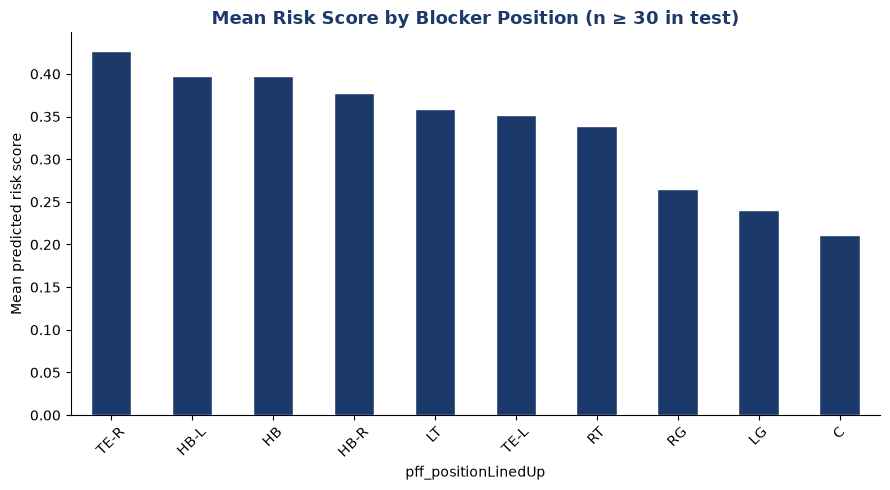

                         mean  count
pff_positionLinedUp                 
TE-R                 0.427330     95
HB-L                 0.397383    106
HB                   0.397253     59
HB-R                 0.377176     87
LT                   0.358557   1706
TE-L                 0.351678     71
RT                   0.338949   1709
RG                   0.264654   1689
LG                   0.240633   1694
C                    0.211550   1683


In [59]:
# Risk score by position — should match EDA order

test_df = feature_table.iloc[test_idx].copy()
test_df["risk_score"] = y_prob
test_df["y_pred"]     = y_pred_opt

risk_by_pos = (
    test_df.groupby("pff_positionLinedUp")["risk_score"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 5))
risk_by_pos["mean"].plot(kind="bar", ax=ax, color=NAVY, edgecolor="white")
ax.set_title("Mean Risk Score by Blocker Position (n ≥ 30 in test)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("Mean predicted risk score")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(risk_by_pos.to_string())

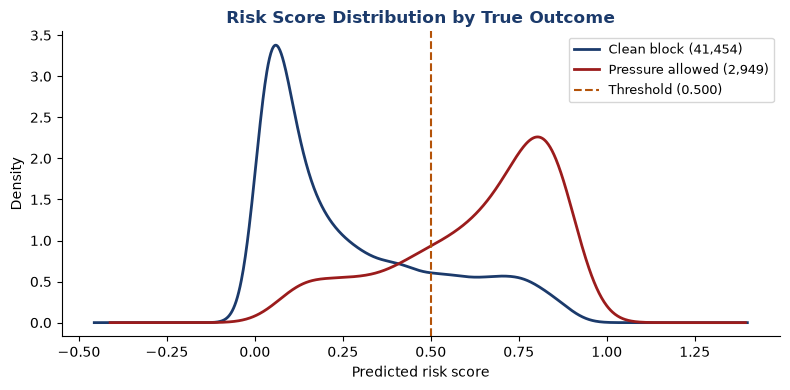

In [60]:
# Risk score distribution: clean vs pressure
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, NAVY, f"Clean block ({neg:,})"),
                            (1, RED,  f"Pressure allowed ({pos:,})")]:
    test_df[test_df["pressure_allowed"] == label]["risk_score"]\
        .plot.kde(ax=ax, color=color, lw=2, label=name)
ax.axvline(best_thresh, color=AMBER, ls="--", label=f"Threshold ({best_thresh:.3f})")
ax.set(xlabel="Predicted risk score", ylabel="Density",
       title="Risk Score Distribution by True Outcome")
ax.title.set(fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### Step 15: Error Analysis

In [61]:
# False Negatives = missed pressure events (costliest error)
fn_df = test_df[(test_df["pressure_allowed"] == 1) & (test_df["y_pred"] == 0)]
tp_df = test_df[(test_df["pressure_allowed"] == 1) & (test_df["y_pred"] == 1)]
fp_df = test_df[(test_df["pressure_allowed"] == 0) & (test_df["y_pred"] == 1)]

print(f"TP (caught pressure) : {len(tp_df):,}")
print(f"FN (missed pressure) : {len(fn_df):,}  ← most costly")
print(f"FP (false alarm)     : {len(fp_df):,}")
print()

compare_cols = ["separation_min", "closing_velocity", "rusher_speed_max"]
compare = pd.concat([
    fn_df[compare_cols].mean().rename("FN (missed)"),
    tp_df[compare_cols].mean().rename("TP (caught)"),
], axis=1).round(3)
print("Tracking features — FN vs TP:")
print(compare.to_string())
print()
print("FN by position:")
print(fn_df["pff_positionLinedUp"].value_counts().head(8).to_string())

TP (caught pressure) : 442
FN (missed pressure) : 162  ← most costly
FP (false alarm)     : 1,716

Tracking features — FN vs TP:
                  FN (missed)  TP (caught)
separation_min          0.817        0.594
closing_velocity        0.458        0.225
rusher_speed_max        4.203        4.895

FN by position:
pff_positionLinedUp
C       36
RG      35
RT      35
LT      21
LG      18
HB-R     6
TE-R     3
TE-L     3


##### Step 16: Save Artifacts & Summary

In [62]:
joblib.dump(hgbt,     ARTIFACT_DIR / "model.joblib")
joblib.dump(lr_pipe,  ARTIFACT_DIR / "lr_model.joblib")
joblib.dump(encoders, ARTIFACT_DIR / "encoders.joblib")

feature_table.to_parquet(ARTIFACT_DIR / "feature_table.parquet", index=False)

# Use the SHAP importance Series computed earlier
pd.DataFrame({"feature": FEATURE_COLS,
              "importance": importance.reindex(FEATURE_COLS).values})\
  .sort_values("importance", ascending=False)\
  .to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

# search.best_params_ holds numpy scalar types (from randint/uniform) — cast to
# native python so json.dump doesn't choke on them.
best_params_json = {k: (v.item() if hasattr(v, "item") else v)
                     for k, v in search.best_params_.items()}
metrics = {
    "pr_auc"          : round(float(pr_auc), 4),
    "roc_auc"         : round(float(roc_auc), 4),
    "lr_pr_auc"       : round(float(lr_pr_auc), 4),
    "baseline_pr_auc" : round(float(baseline_pr_auc), 4),
    "cv_score_mean"   : round(float(cv_score_mean), 4),
    "cv_score_std"    : round(float(cv_score_std), 4),
    "cv_scoring"      : "average_precision",
    "best_params"     : best_params_json,
    "best_threshold"  : round(float(best_thresh), 4),
    "best_f1"         : round(float(best_f1), 4),
    "n_train"         : int(len(X_train)),
    "n_test"          : int(len(X_test)),
    "positive_rate"   : round(float(y_test.mean()), 4),
    "imbalance_ratio" : round(float(neg/pos), 2),
}
with open(ARTIFACT_DIR / "metrics_report.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name}")

Saved:
  encoders.joblib
  feature_importance.csv
  feature_table.parquet
  lr_model.joblib
  metrics_report.json
  model.joblib


In [64]:
print("═" * 58)
print("pressure_allowed RESULTS SUMMARY")
print("═" * 58)
print(f"  Feature rows    : {len(feature_table):,}")
print(f"  Positive rate   : {pos/len(feature_table):.1%}  (14.1:1 imbalance)")
print(f"  Imbalance fix   : class_weight='balanced'")
print(f"  Baseline PR-AUC : {baseline_pr_auc:.4f}")
print(f"  LR PR-AUC       : {lr_pr_auc:.4f}")
print(f"  HGBT PR-AUC     : {pr_auc:.4f}  ← primary metric")
print(f"  HGBT ROC-AUC    : {roc_auc:.4f}")
print(f"  Best threshold  : {best_thresh:.3f}")
print("═" * 58)

══════════════════════════════════════════════════════════
pressure_allowed RESULTS SUMMARY
══════════════════════════════════════════════════════════
  Feature rows    : 44,403
  Positive rate   : 6.6%  (14.1:1 imbalance)
  Imbalance fix   : class_weight='balanced'
  Baseline PR-AUC : 0.0670
  LR PR-AUC       : 0.2005
  HGBT PR-AUC     : 0.2945  ← primary metric
  HGBT ROC-AUC    : 0.8499
  Best threshold  : 0.500
══════════════════════════════════════════════════════════


<!-- CONCLUSION_CELL_13 -->